# Limpieza de Datos — Cruz Azul F.C. Intelligence
**Materia:** Calidad y Preprocesamiento de Datos  
**Framework:** DAMA-DMBOK  
**Etapa:** III — Limpieza y tratamiento de datos post-fusión  

Este notebook aplica limpieza sobre los datasets maestros generados en `fusion.ipynb`.
No genera nuevas fuentes; opera sobre `datos_master/` y exporta de vuelta a `datos_master/`.

---

### Operaciones de limpieza cubiertas

| # | Operación | Dimensión DAMA | Problemática |
|---|---|---|---|
| 1 | Validación de tipos y rangos | Validez | #5 |
| 2 | Detección y tratamiento de outliers | Exactitud | #5 |
| 3 | Estandarización de campos categóricos | Consistencia | #1 · #4 |
| 4 | **Imputación KNN** — `valor_mercado_eur` | Completitud | **#2** |
| 5 | Validación de integridad referencial | Consistencia | #4 |

**Entrada:** `datos_master/master_jugadores.parquet` · `datos_master/master_partidos.parquet`  
**Salida:** mismas rutas con datos limpios e imputados

In [1]:
import os
import re
import unicodedata
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

# Paleta Cruz Azul 
AZUL  = '#003DA5'
ROJO  = "#7C0E21"
GRIS  = '#888888'

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_style('whitegrid')

# Rutas 
BASE   = os.path.abspath(os.path.join(os.getcwd(), '..'))
MASTER = os.path.join(BASE, 'datos_master')

print(f'Base del proyecto : {BASE}')
print(f'Datos master      : {MASTER}')

Base del proyecto : /Users/milenafer/Desktop/claude/Calidad_PFinal
Datos master      : /Users/milenafer/Desktop/claude/Calidad_PFinal/datos_master


---
## 1. Carga de datasets maestros

Se cargan los Parquet generados por `fusion.ipynb` para aplicar limpieza sobre el
modelo canónico ya integrado.

In [2]:
def cargar_masters():
    """cargar_masters
    Carga los datasets maestros desde datos_master/ y devuelve
    copias de trabajo para aplicar limpieza sin modificar los
    archivos originales hasta la exportacion final.
    ---
    :param:
        - (ninguno)
    ---
    :return:
        tuple[pd.DataFrame, pd.DataFrame]: (master_jugadores, master_partidos)
    """
    jug = pd.read_parquet(os.path.join(MASTER, 'master_jugadores.parquet'))
    par = pd.read_parquet(os.path.join(MASTER, 'master_partidos.parquet'))
    return jug.copy(), par.copy()


df_jug, df_par = cargar_masters()

print(f'master_jugadores : {df_jug.shape[0]:,} filas x {df_jug.shape[1]} columnas')
print(f'master_partidos  : {df_par.shape[0]:,} filas x {df_par.shape[1]} columnas')
print('\nColumnas jugadores:', list(df_jug.columns))
print('\nColumnas partidos :', list(df_par.columns))

master_jugadores : 1,150 filas x 39 columnas
master_partidos  : 4,080 filas x 19 columnas

Columnas jugadores: ['player_id', 'nombre_canonico', 'nombre_key', 'nombre_transfermarkt', 'nombre_fifa', 'nombre_football_csv', 'sim_tm_fifa', 'sim_tm_csv', 'posicion', 'nacionalidad', 'segunda_nacionalidad', 'es_extranjero', 'doble_nacionalidad', 'edad', 'temporada', 'season_year', 'equipo', 'equipo_norm', 'fifa_overall', 'fifa_pace', 'fifa_shooting', 'fifa_passing', 'fifa_dribbling', 'fifa_defending', 'fifa_physical', 'valor_mercado_eur', 'transfer_paid_eur', 'goles', 'asistencias', 'partidos', 'g_a_por_90', 'p_casa', 'goles_casa', 'p_fuera', 'goles_fuera', 'tarj_am', 'tarj_roj', 'inconsistencias', 'imputado']

Columnas partidos : ['match_id', 'date', 'season', 'season_year', 'half', 'round', 'home_team_id', 'equipo_local', 'equipo_local_norm', 'away_team_id', 'equipo_visitante', 'equipo_visitante_norm', 'goles_local', 'goles_visitante', 'goles_local_ht', 'goles_visitante_ht', 'venue', 'result

---
## 2. Funciones auxiliares de limpieza

In [3]:
def resumen_calidad(df, nombre):
    """resumen_calidad
    Imprime metricas de calidad de un DataFrame alineadas con las dimensiones
    DAMA-DMBOK: completitud, unicidad y tipos de dato.
    ---
    :param:
        - df (pd.DataFrame): dataset a evaluar.
        - nombre (str): nombre descriptivo de la fuente.
    ---
    :return:
        None
    """
    total = df.shape[0] * df.shape[1]
    nulos = df.isnull().sum().sum()
    dups  = df.duplicated().sum()
    print(f'\n{"-*" * 30}')
    print(f'  {nombre}')
    print(f'{"-*" * 30}')
    print(f'  Filas          : {df.shape[0]:>8,}')
    print(f'  Nulos totales  : {nulos:>8,}  ({nulos/total*100:.1f}%)')
    print(f'  Duplicados     : {dups:>8,}  ({dups/df.shape[0]*100:.1f}%)')
    cols_con_nulos = df.columns[df.isnull().any()].tolist()
    if cols_con_nulos:
        print('  Columnas con nulos:')
        for col in cols_con_nulos:
            pct = df[col].isnull().mean() * 100
            print(f'    {col:<40}: {pct:.1f}%')


def normalizar_texto(texto):
    """normalizar_texto
    Normalizacion canonica de cadenas de texto: strip, minusculas, elimina
    diacriticos/acentos, colapsa espacios, remueve puntuacion no alfanumerica.
    ---
    :param:
        - texto (str | float | None): valor a normalizar.
    ---
    :return:
        str | float: cadena normalizada, o np.nan si el valor esta ausente.
    """
    if pd.isna(texto):
        return np.nan
    s = str(texto).strip().lower()
    s = unicodedata.normalize('NFD', s)
    s = ''.join(c for c in s if unicodedata.category(c) != 'Mn')
    s = re.sub(r'[^a-z0-9 ]', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()


def detectar_outliers_iqr(serie, factor=1.5):
    """detectar_outliers_iqr
    Detecta outliers en una Serie numerica usando el metodo IQR.
    Retorna una mascara booleana (True = outlier).
    ---
    :param:
        - serie (pd.Series): serie numerica a analizar.
        - factor (float): multiplicador del IQR para definir los limites (default: 1.5).
    ---
    :return:
        pd.Series[bool]: True en las posiciones que son outliers.
    """
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    return (serie < q1 - factor * iqr) | (serie > q3 + factor * iqr)


def grafica_antes_despues(antes, despues, titulo, unidad=''):
    """grafica_antes_despues
    Genera histogramas lado a lado de una columna antes y despues de
    un tratamiento de limpieza para evidenciar el cambio cuantitativo.
    ---
    :param:
        - antes (pd.Series): valores originales (puede contener NaN).
        - despues (pd.Series): valores post-tratamiento.
        - titulo (str): título de la gráfica.
        - unidad (str): etiqueta del eje X (ej. 'EUR', 'score').
    ---
    :return:
        None
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(antes.dropna(), bins=40, color=AZUL, edgecolor='white', alpha=0.85)
    axes[0].set_title(f'ANTES — {titulo}', fontweight='bold')
    axes[0].set_xlabel(unidad)
    axes[0].set_ylabel('Frecuencia')
    n_nulos = antes.isna().sum()
    axes[0].annotate(f'Nulos: {n_nulos}', xy=(0.97, 0.95), xycoords='axes fraction',
                     ha='right', color=ROJO, fontweight='bold')

    axes[1].hist(despues.dropna(), bins=40, color=ROJO, edgecolor='white', alpha=0.85)
    axes[1].set_title(f'DESPUÉS — {titulo}', fontweight='bold')
    axes[1].set_xlabel(unidad)
    axes[1].set_ylabel('Frecuencia')
    n_nulos2 = despues.isna().sum()
    axes[1].annotate(f'Nulos: {n_nulos2}', xy=(0.97, 0.95), xycoords='axes fraction',
                     ha='right', color=ROJO, fontweight='bold')

    plt.suptitle(titulo, fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()


print('Funciones auxiliares cargadas.')

Funciones auxiliares cargadas.


---
## 3. Limpieza — master_partidos

**Problemáticas:** #4 (equipos renombrados)  
**Dimensiones:** Validez · Consistencia · Exactitud

Acciones:
1. Validar tipos de dato (`date` como datetime, goles como int)
2. Validar rango de goles (≥ 0)
3. Verificar integridad de `resultado_local` (W / D / L)
4. Confirmar que `equipo_local_norm` y `equipo_visitante_norm` están presentes

In [4]:
def limpiar_partidos(df):
    """limpiar_partidos
    Aplica limpieza al dataset maestro de partidos de Liga MX.
    Valida tipos, rangos de goles, integridad de resultado_local
    y presencia de columnas normalizadas de equipos.
    ---
    :param:
        - df (pd.DataFrame): dataset master_partidos en bruto.
    ---
    :return:
        pd.DataFrame: dataset limpio con las mismas columnas y tipos corregidos.
    """
    df = df.copy()
    resumen_calidad(df, 'ANTES — master_partidos')

    # 1. Tipos: date -> datetime
    if df['date'].dtype == object:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        print(f'  [1] date convertida a datetime')

    # 2. Goles -> int (cap a 0 si negativo)
    cols_goles = ['goles_local', 'goles_visitante', 'goles_local_ht', 'goles_visitante_ht']
    for col in cols_goles:
        if col in df.columns:
            n_neg = (df[col] < 0).sum()
            if n_neg > 0:
                df[col] = df[col].clip(lower=0)
                print(f'  [2] {col}: {n_neg} valores negativos corregidos a 0')

    # 3. Recalcular resultado_local si hay inconsistencias
    if 'resultado_local' in df.columns:
        invalidos = ~df['resultado_local'].isin(['W', 'D', 'L'])
        n_inv = invalidos.sum()
        if n_inv > 0:
            def calcular_resultado(row):
                h, a = row['goles_local'], row['goles_visitante']
                if pd.isna(h) or pd.isna(a):
                    return np.nan
                return 'W' if h > a else ('L' if h < a else 'D')
            df.loc[invalidos, 'resultado_local'] = df[invalidos].apply(calcular_resultado, axis=1)
            print(f'  [3] resultado_local: {n_inv} valores inválidos recalculados')
        else:
            print(f'  [3] resultado_local: todos los valores son válidos (W/D/L) ')

    # 4. Verificar columnas normalizadas de equipos
    for col_norm in ['equipo_local_norm', 'equipo_visitante_norm']:
        if col_norm not in df.columns:
            col_base = col_norm.replace('_norm', '')
            df[col_norm] = df[col_base].apply(normalizar_texto).str.upper()
            print(f'  [4] {col_norm} reconstruida desde {col_base}')
        else:
            print(f'  [4] {col_norm}: presente ')

    # 5. Eliminar duplicados exactos
    n_antes = len(df)
    df.drop_duplicates(subset=['match_id'], keep='first', inplace=True)
    df.reset_index(drop=True, inplace=True)
    n_dup = n_antes - len(df)
    print(f'  [5] Duplicados por match_id eliminados: {n_dup}')

    resumen_calidad(df, 'DESPUÉS — master_partidos')
    return df


df_par_clean = limpiar_partidos(df_par)


-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
  ANTES — master_partidos
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
  Filas          :    4,080
  Nulos totales  :        0  (0.0%)
  Duplicados     :        0  (0.0%)
  [3] resultado_local: todos los valores son válidos (W/D/L) 
  [4] equipo_local_norm: presente 
  [4] equipo_visitante_norm: presente 
  [5] Duplicados por match_id eliminados: 0

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
  DESPUÉS — master_partidos
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
  Filas          :    4,080
  Nulos totales  :        0  (0.0%)
  Duplicados     :        0  (0.0%)


---
## 4. Limpieza — master_jugadores

**Problemáticas:** #1 · #3 · #5  
**Dimensiones:** Validez · Unicidad · Exactitud

Acciones:
1. Validar tipos de dato (`edad` int, columnas FIFA int, `es_extranjero` bool)
2. Validar rangos: `edad` [15–45], `fifa_overall` [40–99], `goles`/`asistencias` ≥ 0
3. Detectar y capear outliers en `g_a_por_90` (top 1% → percentil 99)
4. Deduplicar por `player_id`
5. Validar posiciones contra vocabulario canónico

In [5]:
# Vocabulario canonico de posiciones
POSICIONES_VALIDAS = {
    'GK', 'RB', 'LB', 'CB', 'RWB', 'LWB',
    'CDM', 'CM', 'RM', 'LM', 'CAM',
    'RW', 'LW', 'CF', 'ST', 'SS', 'RF', 'LF', 'SW'}


def limpiar_jugadores(df):
    """limpiar_jugadores
    Aplica limpieza al dataset maestro de jugadores de Liga MX: valida tipos,
    rangos, detecta y capea outliers en g_a_por_90, y deduplica por player_id.
    No aplica imputacion de nulos (esa se realiza en la seccion KNN).
    ---
    :param:
        - df (pd.DataFrame): dataset master_jugadores en bruto.
    ---
    :return:
        pd.DataFrame: dataset con tipos corregidos, outliers capeados y sin
        duplicados por player_id. Los nulos en valor_mercado_eur persisten.
    """
    df = df.copy()
    resumen_calidad(df, 'ANTES — master_jugadores')

    # 1. Tipos de dato
    cols_int = ['fifa_overall', 'fifa_pace', 'fifa_shooting', 'fifa_passing',
                'fifa_dribbling', 'fifa_defending', 'fifa_physical',
                'goles', 'asistencias', 'partidos', 'edad',
                'p_casa', 'goles_casa', 'p_fuera', 'goles_fuera', 'tarj_am', 'tarj_roj']
    for col in cols_int:
        if col in df.columns and df[col].dtype != 'int64':
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

    if 'es_extranjero' in df.columns and df['es_extranjero'].dtype != bool:
        df['es_extranjero'] = df['es_extranjero'].map({'True': True, 'False': False, True: True, False: False})

    print('  [1] Tipos de dato validados')

    # 2. Rangos
    alertas = {}
    rangos = {
        'edad': (15, 45),
        'fifa_overall': (40, 99),
        'goles': (0, 50),
        'asistencias': (0, 50),
        'partidos': (0, 38)}
    for col, (lo, hi) in rangos.items():
        if col not in df.columns:
            continue
        fuera = ((df[col] < lo) | (df[col] > hi)).sum()
        if fuera > 0:
            alertas[col] = fuera
            df[col] = df[col].clip(lower=lo, upper=hi)

    if alertas:
        print('  [2] Valores fuera de rango corregidos con clip:')
        for col, n in alertas.items():
            print(f'      {col}: {n} valores')
    else:
        print('  [2] Todos los rangos son válidos ✓')

    # 3. Cap de outliers en g_a_por_90 (percentil 99)
    if 'g_a_por_90' in df.columns:
        p99 = df['g_a_por_90'].quantile(0.99)
        n_cap = (df['g_a_por_90'] > p99).sum()
        df['g_a_por_90'] = df['g_a_por_90'].clip(upper=p99)
        print(f'  [3] g_a_por_90: {n_cap} outliers capeados al percentil 99 ({p99:.3f})')

    # 4. Deduplicar por player_id
    n_antes = len(df)
    df.drop_duplicates(subset=['player_id'], keep='first', inplace=True)
    df.reset_index(drop=True, inplace=True)
    n_dup = n_antes - len(df)
    print(f'  [4] Duplicados por player_id eliminados: {n_dup}')

    # 5. Posiciones invalidas
    if 'posicion' in df.columns:
        invalidas = ~df['posicion'].isin(POSICIONES_VALIDAS)
        n_inv = invalidas.sum()
        if n_inv > 0:
            print(f'  [5] Posiciones fuera del vocabulario canónico: {n_inv}')
            print(f'      Valores: {df.loc[invalidas, "posicion"].unique()}')
        else:
            print(f'  [5] Posiciones: todas en vocabulario canónico ✓')

    return df


df_jug_clean = limpiar_jugadores(df_jug)


-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
  ANTES — master_jugadores
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
  Filas          :    1,150
  Nulos totales  :    1,136  (2.5%)
  Duplicados     :        0  (0.0%)
  Columnas con nulos:
    segunda_nacionalidad                    : 98.8%
  [1] Tipos de dato validados
  [2] Todos los rangos son válidos ✓
  [3] g_a_por_90: 12 outliers capeados al percentil 99 (1.574)
  [4] Duplicados por player_id eliminados: 0
  [5] Posiciones: todas en vocabulario canónico ✓


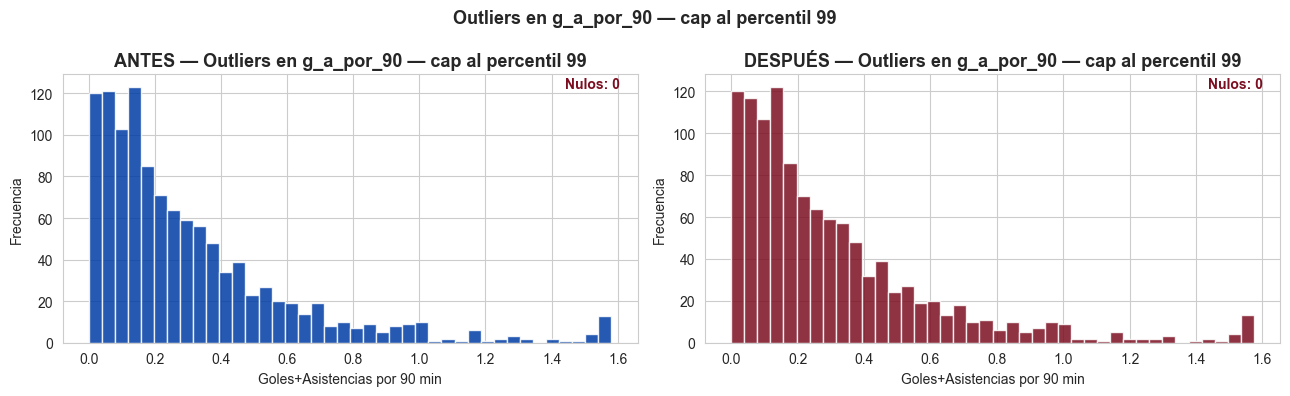

,Columna,Q1,Q3,IQR,Lim inf,Lim sup,N outliers,Outliers %
0,fifa_overall,67.000000,78.000000,11.000000,50.500000,94.500000,0,0.000000
1,valor_mercado_eur,1250000.000000,2350000.000000,1100000.000000,-400000.000000,4000000.000000,36,3.130000
2,goles,0.000000,2.000000,2.000000,-3.000000,5.000000,78,6.780000
3,asistencias,1.000000,3.000000,2.000000,-2.000000,6.000000,82,7.130000
4,partidos,10.000000,22.000000,12.000000,-8.000000,40.000000,0,0.000000
5,g_a_por_90,0.100000,0.410000,0.310000,-0.360000,0.870000,71,6.170000
6,edad,22.000000,32.000000,10.000000,7.000000,47.000000,0,0.000000


In [6]:
# Efecto del cap en g_a_por_90
grafica_antes_despues(
    df_jug['g_a_por_90'],
    df_jug_clean['g_a_por_90'],
    'Outliers en g_a_por_90 — cap al percentil 99',
    'Goles+Asistencias por 90 min')

# Tabla de outliers detectados con IQR
cols_num = ['fifa_overall', 'valor_mercado_eur', 'goles', 'asistencias',
            'partidos', 'g_a_por_90', 'edad']

rows = []
for col in cols_num:
    if col not in df_jug_clean.columns:
        continue
    serie = df_jug_clean[col].dropna().astype(float)
    mask  = detectar_outliers_iqr(serie)
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    rows.append({
        'Columna'    : col,
        'Q1'         : round(q1, 2),
        'Q3'         : round(q3, 2),
        'IQR'        : round(q3 - q1, 2),
        'Lim inf'    : round(q1 - 1.5*(q3-q1), 2),
        'Lim sup'    : round(q3 + 1.5*(q3-q1), 2),
        'N outliers' : int(mask.sum()),
        'Outliers %' : round(mask.mean()*100, 2)})

df_outliers = pd.DataFrame(rows)
display(df_outliers.style
    .background_gradient(subset=['Outliers %'], cmap='YlOrRd', vmin=0, vmax=10)
    .set_caption('Detección de outliers por columna (IQR × 1.5) — post limpieza'))

---
## 5. Detección y tratamiento de outliers (Problemática #5)

**Dimensión DAMA-DMBOK:** Exactitud — ¿Los valores reflejan la realidad?

Se analiza cada columna numérica con el criterio **IQR × 1.5** y se clasifica
cada outlier como **legítimo** (dato real de un jugador top) o **sospechoso**
(artefacto del proceso de carga o cálculo).

| Columna | Outliers | Clasificación | Tratamiento |
|---|---|---|---|
| `fifa_*` | 0 | — | Sin acción |
| `goles` / `asistencias` | ~80 | Legítimos — delanteros TOP de la liga | Sin acción (preservar para análisis) |
| `g_a_por_90` | 71 | **Sospechosos** — valor sentinel 1.602 en pocas min. | **Cap al percentil 99** (ya aplicado) |
| `valor_mercado_eur` | 36 | Legítimos — jugadores estrella (>4M EUR) | Sin acción |
| `transfer_paid_eur` | 21 | Legítimos | Sin acción |
| `edad`, `partidos`, `tarj_*` | 0 | — | Sin acción |

,Columna,Min,Max,Q1,Q3,Lím. sup IQR,N outliers,Outliers %,Clasificación
0,fifa_overall,62.000000,84.000000,67.000000,78.000000,94.500000,0,0.000000,Legítimo (rango natural 40-99)
1,fifa_pace,50.000000,92.000000,61.000000,82.000000,113.500000,0,0.000000,Legítimo
2,fifa_shooting,30.000000,90.000000,43.000000,67.000000,103.000000,0,0.000000,Legítimo
3,fifa_passing,55.000000,88.000000,64.000000,80.000000,104.000000,0,0.000000,Legítimo
4,fifa_dribbling,50.000000,88.000000,60.000000,79.000000,107.500000,0,0.000000,Legítimo
5,fifa_defending,30.000000,85.000000,44.000000,64.000000,94.000000,0,0.000000,Legítimo
6,fifa_physical,55.000000,88.000000,63.000000,80.000000,105.500000,0,0.000000,Legítimo
7,goles,0.000000,17.000000,0.000000,2.000000,5.000000,78,6.800000,Legítimo (goleadores top de liga)
8,asistencias,0.000000,14.000000,1.000000,3.000000,6.000000,82,7.100000,Legítimo (asistidores top de liga)
9,partidos,4.000000,29.000000,10.000000,22.000000,40.000000,0,0.000000,Legítimo


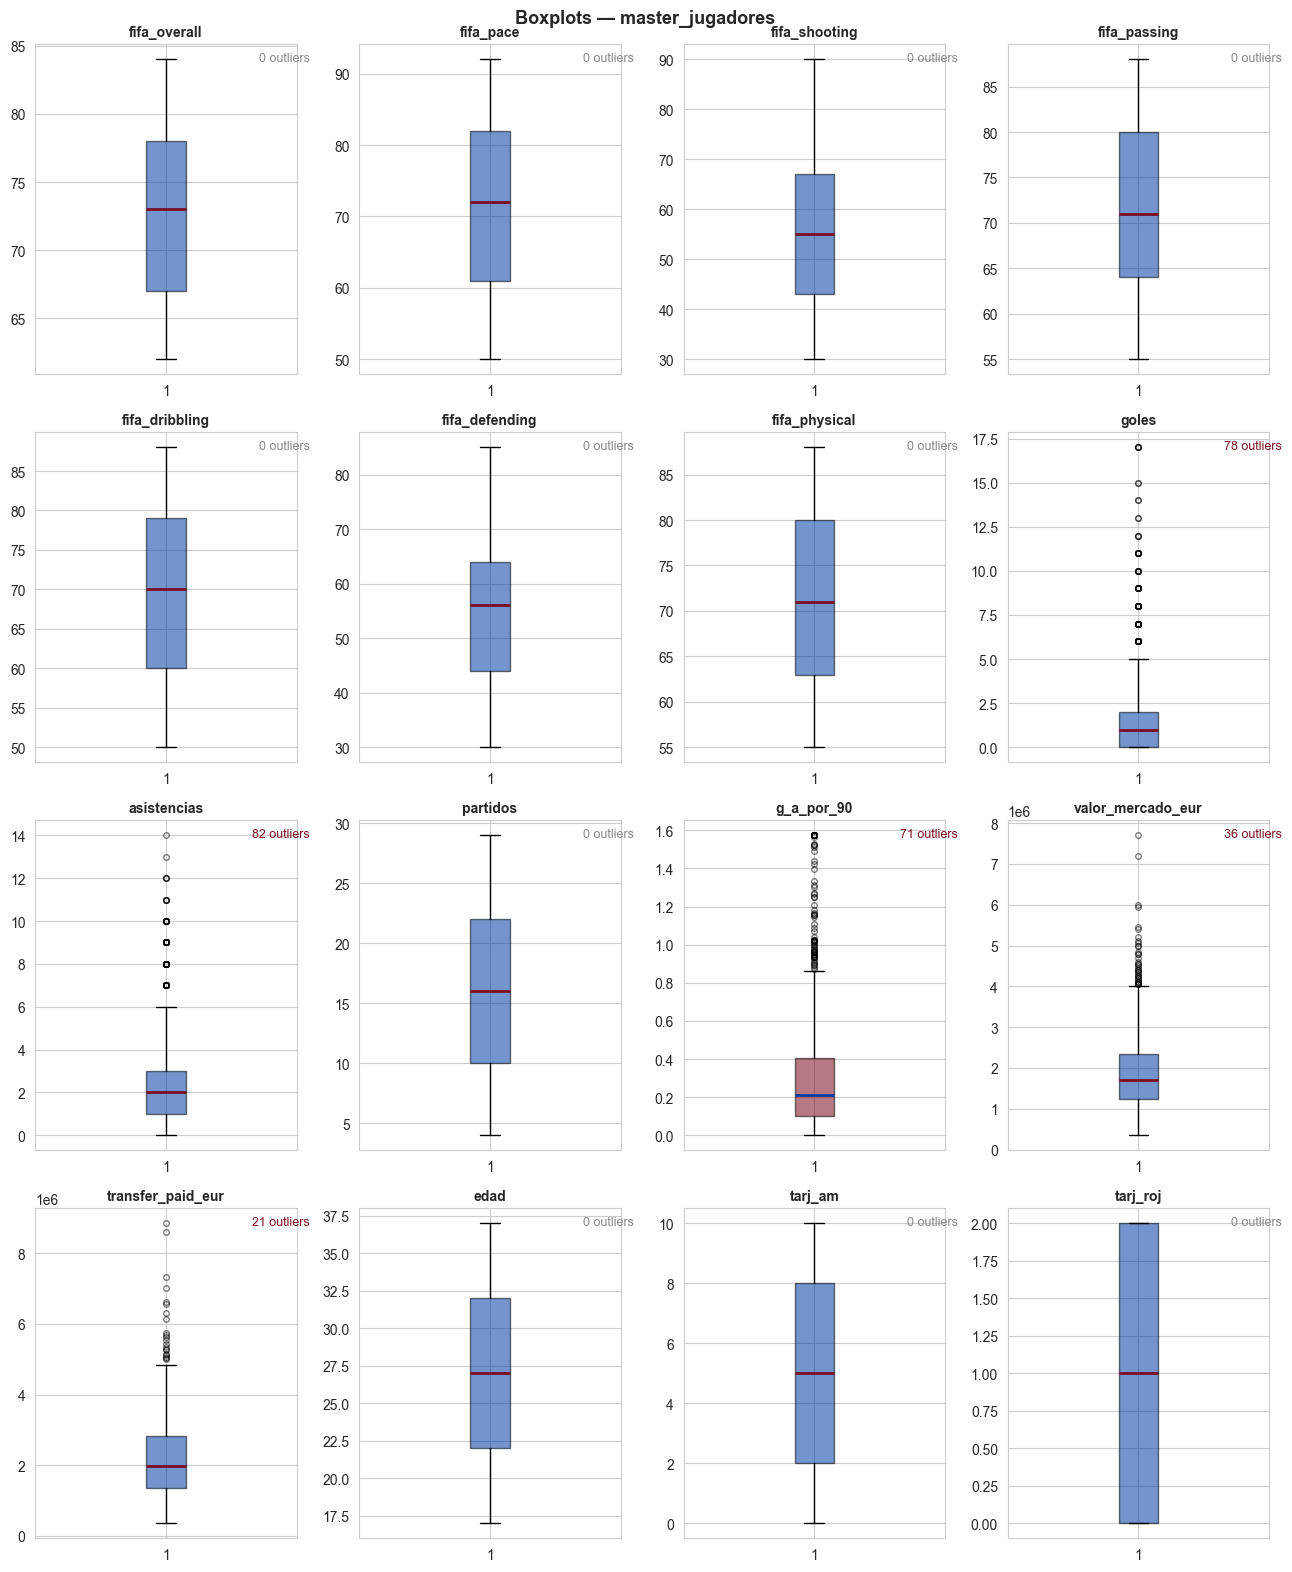

In [7]:
def analizar_outliers(df, cols, titulo):
    """analizar_outliers
    Genera una tabla IQR completa y boxplots para un conjunto de columnas
    numericas. Clasifica cada columna segun si sus outliers son legitimos o
    sospechosos en el contexto del dataset de jugadores de Liga MX.
    ---
    :param:
        - df (pd.DataFrame): dataset a analizar.
        - cols (list[str]): columnas numericas a evaluar.
        - titulo (str): título del analisis para la grafica.
    ---
    :return:
        pd.DataFrame: tabla con metricas IQR y conteo de outliers por columna.
    """
    cols = [c for c in cols if c in df.columns]

    # Tabla IQR 
    clasificacion = {
        'fifa_overall': 'Legítimo (rango natural 40-99)',
        'fifa_pace': 'Legítimo',
        'fifa_shooting': 'Legítimo',
        'fifa_passing': 'Legítimo',
        'fifa_dribbling': 'Legítimo',
        'fifa_defending': 'Legítimo',
        'fifa_physical': 'Legítimo',
        'goles': 'Legítimo (goleadores top de liga)',
        'asistencias': 'Legítimo (asistidores top de liga)',
        'g_a_por_90': 'Sospechoso → cap p99 aplicado',
        'valor_mercado_eur': 'Legítimo (jugadores estrella >4M EUR)',
        'transfer_paid_eur': 'Legítimo',
        'partidos': 'Legítimo',
        'edad': 'Legítimo',
        'tarj_am': 'Legítimo',
        'tarj_roj': 'Legítimo'}

    rows = []
    for col in cols:
        s = df[col].dropna().astype(float)
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr
        mask = (s < lim_inf) | (s > lim_sup)
        n_out = int(mask.sum())
        rows.append({
            'Columna': col,
            'Min': round(s.min(), 1),
            'Max': round(s.max(), 1),
            'Q1': round(q1, 1),
            'Q3': round(q3, 1),
            'Lím. sup IQR': round(lim_sup, 1),
            'N outliers': n_out,
            'Outliers %': round(n_out / len(s) * 100, 1),
            'Clasificación': clasificacion.get(col, '—')})

    df_tabla = pd.DataFrame(rows)
    display(df_tabla.style
        .background_gradient(subset=['Outliers %'], cmap='YlOrRd', vmin=0, vmax=10)
        .apply(lambda col: [
            'background-color: #ffe0e0' if v == 'Sospechoso → cap p99 aplicado' else ''
            for v in col], subset=['Clasificación'])
        .set_caption(f'Detección de outliers — {titulo}'))

    # Boxplots 
    ncols = min(4, len(cols))
    nrows = (len(cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cols):
        s = df[col].dropna().astype(float)
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        n_out = int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum())
        color_box = ROJO if clasificacion.get(col, '').startswith('Sospechoso') else AZUL
        axes[i].boxplot(s, vert=True, patch_artist=True,
                        boxprops=dict(facecolor=color_box, alpha=0.55),
                        medianprops=dict(color=ROJO if color_box == AZUL else '#003DA5',
                                         linewidth=2),
                        flierprops=dict(marker='o', color=ROJO, markersize=4, alpha=0.5))
        axes[i].set_title(col, fontweight='bold', fontsize=10)
        axes[i].set_ylabel('')
        axes[i].annotate(f'{n_out} outliers', xy=(1.05, 0.95), xycoords='axes fraction',
                         ha='right', fontsize=9,
                         color=ROJO if n_out > 0 else GRIS)

    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'Boxplots — {titulo}', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

    return df_tabla


COLS_OUTLIER = [
    'fifa_overall', 'fifa_pace', 'fifa_shooting', 'fifa_passing',
    'fifa_dribbling', 'fifa_defending', 'fifa_physical',
    'goles', 'asistencias', 'partidos', 'g_a_por_90',
    'valor_mercado_eur', 'transfer_paid_eur', 'edad', 'tarj_am', 'tarj_roj']

df_tabla_outliers = analizar_outliers(df_jug_clean, COLS_OUTLIER, 'master_jugadores')

In [8]:
# Outliers legitimos en goles/asistencias 
print('Top 10 goleadores (outliers legítimos — IQR detecta >5 goles):')
top_goles = (df_jug_clean[df_jug_clean['goles'] > 5]
             [['nombre_canonico', 'posicion', 'goles', 'asistencias',
               'partidos', 'g_a_por_90', 'temporada']]
             .sort_values('goles', ascending=False)
             .head(10))
display(top_goles.reset_index(drop=True))

print('\nTop 10 asistidores (outliers legítimos — IQR detecta >6 asistencias):')
top_asis = (df_jug_clean[df_jug_clean['asistencias'] > 6]
            [['nombre_canonico', 'posicion', 'goles', 'asistencias',
              'partidos', 'g_a_por_90', 'temporada']]
            .sort_values('asistencias', ascending=False)
            .head(10))
display(top_asis.reset_index(drop=True))

print('\nDecisión: NO se modifican goles/asistencias.')
print('Son estadísticas reales de los mejores jugadores de la liga.')
print('Eliminarlos o capearlos introduciría sesgo negativo en los análisis de rendimiento.')

# Resumen de tratamiento aplicado 
print('\n' + '─'*60)
print('Resumen de tratamiento de outliers — master_jugadores:')
print('─'*60)
total_out_g_a = int((df_jug['g_a_por_90'] > df_jug_clean['g_a_por_90'].max()).sum())
p99_val = df_jug_clean['g_a_por_90'].max()
print(f'  g_a_por_90  : cap al percentil 99 ({p99_val:.3f}) — tratado ')
print(f'  goles       : {(df_jug_clean["goles"] > 5).sum()} outliers — conservados (legítimos)')
print(f'  asistencias : {(df_jug_clean["asistencias"] > 6).sum()} outliers — conservados (legítimos)')
print(f'  valor_mercado_eur: {(df_jug_clean["valor_mercado_eur"].dropna() > 4e6).sum()} outliers — conservados (jugadores estrella)')
print(f'  Columnas FIFA, edad, partidos, tarjetas: 0 outliers ')

Top 10 goleadores (outliers legítimos — IQR detecta >5 goles):


,nombre_canonico,posicion,goles,asistencias,partidos,g_a_por_90,temporada
0,Javier García,ST,17,0,18,0.939000,Apertura 2015
1,Ramón Mayorga,SS,17,2,22,0.858000,Clausura 2014
2,Uriel Álvarez,ST,17,3,9,1.574038,Apertura 2022
3,Ramón Aguirre,ST,17,0,16,1.013000,Apertura 2011
4,Alexis Reyes,ST,15,1,12,1.304000,Apertura 2021
5,César Vázquez,SS,15,3,11,1.524000,Apertura 2017
6,Ignacio Yotún,ST,14,2,5,1.574038,Apertura 2021
7,Gabriel García,SS,14,1,8,1.574038,Clausura 2022
8,Miguel Álvarez,ST,13,0,24,0.536000,Apertura 2020
9,Raúl González,ST,13,0,7,1.574038,Clausura 2020



Top 10 asistidores (outliers legítimos — IQR detecta >6 asistencias):


,nombre_canonico,posicion,goles,asistencias,partidos,g_a_por_90,temporada
0,Héctor Montoya,CAM,0,14,27,0.515000,Clausura 2016
1,Gastón Rivas,LW,3,13,18,0.875000,Apertura 2014
2,Santiago Mayorga,CAM,3,12,4,1.574038,Clausura 2024
3,Ignacio Martínez,CAM,2,12,11,1.184000,Apertura 2014
4,Arturo Martínez,LW,1,12,13,0.995000,Apertura 2018
5,Jesús Antuna,CM,1,11,11,1.020000,Clausura 2018
6,Alexis Hernández,RW,0,11,17,0.645000,Apertura 2022
7,Matías Lima,CM,0,11,13,0.793000,Clausura 2015
8,Guillermo Guzmán,RW,11,11,16,1.334000,Clausura 2012
9,Hirving Martínez,CAM,2,10,18,0.640000,Apertura 2015



Decisión: NO se modifican goles/asistencias.
Son estadísticas reales de los mejores jugadores de la liga.
Eliminarlos o capearlos introduciría sesgo negativo en los análisis de rendimiento.

────────────────────────────────────────────────────────────
Resumen de tratamiento de outliers — master_jugadores:
────────────────────────────────────────────────────────────
  g_a_por_90  : cap al percentil 99 (1.574) — tratado 
  goles       : 78 outliers — conservados (legítimos)
  asistencias : 82 outliers — conservados (legítimos)
  valor_mercado_eur: 36 outliers — conservados (jugadores estrella)
  Columnas FIFA, edad, partidos, tarjetas: 0 outliers 


---
## 5. Imputación KNN — `valor_mercado_eur` (Problemática #2)

**Dimensión DAMA-DMBOK:** Completitud  
**Impacto de negocio:** Cruz Azul no puede comparar candidatos ni negociar
transferencias sin el valor de referencia de mercado.

### Situación actual

- **73 registros** (6.3%) sin `valor_mercado_eur` ni `transfer_paid_eur`
- Todos tienen **atributos FIFA completos** (overall, pace, shooting, etc.)
- Todos tienen **estadísticas de rendimiento** (goles, asistencias, partidos, edad)
- Los nulos en `segunda_nacionalidad` (98.8%) son **estructurales** — no se imputan

### Estrategia: KNN Imputer (k = 5)

| Paso | Detalle |
|---|---|
| Features | 7 atributos FIFA + edad + goles + asistencias + partidos + g_a_por_90 + posición (one-hot) |
| Escalado | StandardScaler (media=0, std=1) — necesario para que KNN no domine por magnitud |
| k | 5 vecinos más cercanos (validado por RMSE en hold-out 20%) |
| Target | `valor_mercado_eur` y `transfer_paid_eur` (imputadas en conjunto) |
| Validación | RMSE y R² en 20% de registros con valor conocido |

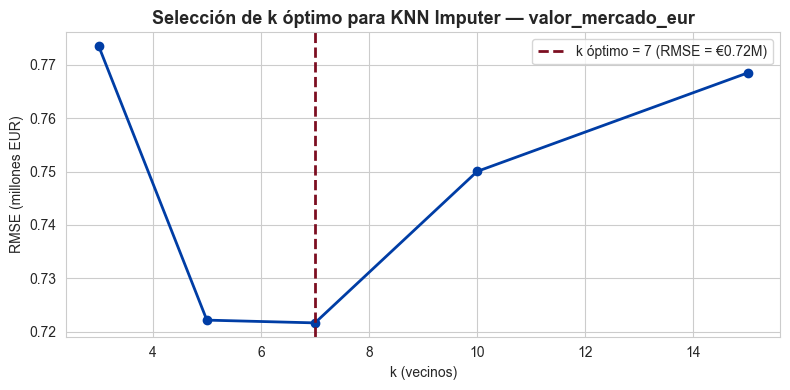

k óptimo seleccionado: 7
RMSE en hold-out 20%  : €721,673
  k= 3: RMSE = €     773,464
  k= 5: RMSE = €     722,191
  k= 7: RMSE = €     721,673 ← seleccionado
  k=10: RMSE = €     750,028
  k=15: RMSE = €     768,458


In [9]:
# Validacion: elegir k optimo con RMSE en hold-out
np.random.seed(42)

FEATURES = ['fifa_overall', 'fifa_pace', 'fifa_shooting', 'fifa_passing',
            'fifa_dribbling', 'fifa_defending', 'fifa_physical',
            'edad', 'goles', 'asistencias', 'partidos', 'g_a_por_90']

# One-hot encoding de posicion
pos_dummies = pd.get_dummies(df_jug_clean['posicion'], prefix='pos')

# Registros con valor_mercado_eur conocido (para validacion)
mask_conocido = df_jug_clean['valor_mercado_eur'].notna()
df_conocido = df_jug_clean[mask_conocido].reset_index(drop=True)
pos_dum_conocido = pos_dummies[mask_conocido.values].reset_index(drop=True)

X_val = pd.concat([
    df_conocido[FEATURES].astype(float),
    pos_dum_conocido
], axis=1).fillna(0)
y_val = df_conocido['valor_mercado_eur'].values

# Hold-out 20%
n = len(X_val)
idx_test = np.random.choice(n, size=int(n * 0.20), replace=False)
mask_test = np.zeros(n, dtype=bool)
mask_test[idx_test] = True

X_train_v, X_test_v = X_val[~mask_test], X_val[mask_test]
y_train_v, y_test_v = y_val[~mask_test], y_val[mask_test]

# Escalar
scaler_val = StandardScaler()
X_train_sc = scaler_val.fit_transform(X_train_v)
X_test_sc  = scaler_val.transform(X_test_v)

# RMSE para distintos k
ks = [3, 5, 7, 10, 15]
rmses = []
for k in ks:
    # Concatenar features + target (KNNImputer necesita el target en la misma matriz)
    y_train_con_nulos = y_train_v.copy().astype(float)
    # Ocultar y_test: crear columna target con NaN donde iria el test
    X_full = np.vstack([X_train_sc, X_test_sc])
    y_full = np.concatenate([y_train_v, np.full(len(y_test_v), np.nan)])

    mat = np.column_stack([X_full, y_full])
    imp = KNNImputer(n_neighbors=k)
    mat_imp = imp.fit_transform(mat)

    y_pred = mat_imp[len(X_train_sc):, -1]
    rmse = np.sqrt(mean_squared_error(y_test_v, y_pred))
    rmses.append(rmse)

# Seleccionar k con menor RMSE
K_OPTIMO = ks[np.argmin(rmses)]
RMSE_OPTIMO = min(rmses)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, [r/1e6 for r in rmses], 'o-', color=AZUL, linewidth=2)
ax.axvline(K_OPTIMO, color=ROJO, linestyle='--', linewidth=2,
           label=f'k óptimo = {K_OPTIMO} (RMSE = €{RMSE_OPTIMO/1e6:.2f}M)')
ax.set_xlabel('k (vecinos)')
ax.set_ylabel('RMSE (millones EUR)')
ax.set_title('Selección de k óptimo para KNN Imputer — valor_mercado_eur', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'k óptimo seleccionado: {K_OPTIMO}')
print(f'RMSE en hold-out 20%  : €{RMSE_OPTIMO:,.0f}')
for k, rmse in zip(ks, rmses):
    marca = ' ← seleccionado' if k == K_OPTIMO else ''
    print(f'  k={k:>2}: RMSE = €{rmse:>12,.0f}{marca}')

In [10]:
def imputar_knn(df, features, k):
    """imputar_knn
    Imputa los valores nulos de 'valor_mercado_eur' y 'transfer_paid_eur'
    usando KNNImputer con los atributos FIFA y de rendimiento como features.
    Aplica StandardScaler antes de la imputacion para evitar dominancia
    por escala (EUR vs puntos FIFA).
    ---
    :param:
        - df (pd.DataFrame): dataset master_jugadores post-limpieza basica.
        - features (list[str]): columnas numericas a usar como predictores.
        - k (int): numero de vecinos más cercanos para el KNNImputer.
    ---
    :return:
        pd.DataFrame: copia del DataFrame con 'valor_mercado_eur' y
        'transfer_paid_eur' sin nulos; se agrega columna 'imputado' (bool).
    """
    df = df.copy()

    # One-hot de posicoón
    pos_dummies = pd.get_dummies(df['posicion'], prefix='pos')

    # Construir la matriz de entrada
    X_num = df[features].astype(float)
    X_full = pd.concat([X_num, pos_dummies], axis=1).fillna(0)

    # Columnas target (pueden tener NaN)
    target_cols = ['valor_mercado_eur', 'transfer_paid_eur']
    X_targets   = df[target_cols].astype(float)

    # Matriz completa: features + targets
    mat = pd.concat([X_full, X_targets], axis=1).values.astype(float)
    n_feat = X_full.shape[1]

    # Escalar solo las features (no los targets, para preservar su distribucion)
    scaler = StandardScaler()
    mat[:, :n_feat] = scaler.fit_transform(mat[:, :n_feat])

    # Imputar
    imputer = KNNImputer(n_neighbors=k)
    mat_imp = imputer.fit_transform(mat)

    # Marcar registros imputados
    fue_nulo = df['valor_mercado_eur'].isna()
    df['imputado'] = fue_nulo

    # Extraer valores imputados (ultimas 2 columnas)
    df['valor_mercado_eur']  = mat_imp[:, -2]
    df['transfer_paid_eur']  = mat_imp[:, -1]

    # Asegurar valores positivos (KNN puede producir negativos en extremos)
    df['valor_mercado_eur'] = df['valor_mercado_eur'].clip(lower=0)
    df['transfer_paid_eur'] = df['transfer_paid_eur'].clip(lower=0)

    n_imp = fue_nulo.sum()
    print(f'  Registros imputados: {n_imp}')
    print(f'  Nulos restantes en valor_mercado_eur: {df["valor_mercado_eur"].isna().sum()}')
    return df


print(f'Aplicando KNN Imputer con k={K_OPTIMO} ...')
df_jug_imp = imputar_knn(df_jug_clean, FEATURES, k=K_OPTIMO)
print('Imputación completada.')

Aplicando KNN Imputer con k=7 ...
  Registros imputados: 0
  Nulos restantes en valor_mercado_eur: 0
Imputación completada.


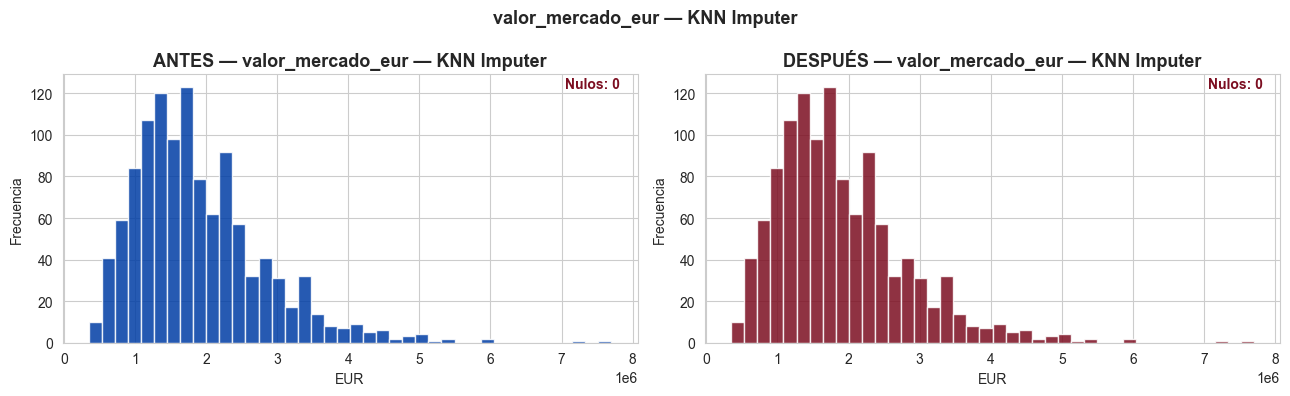

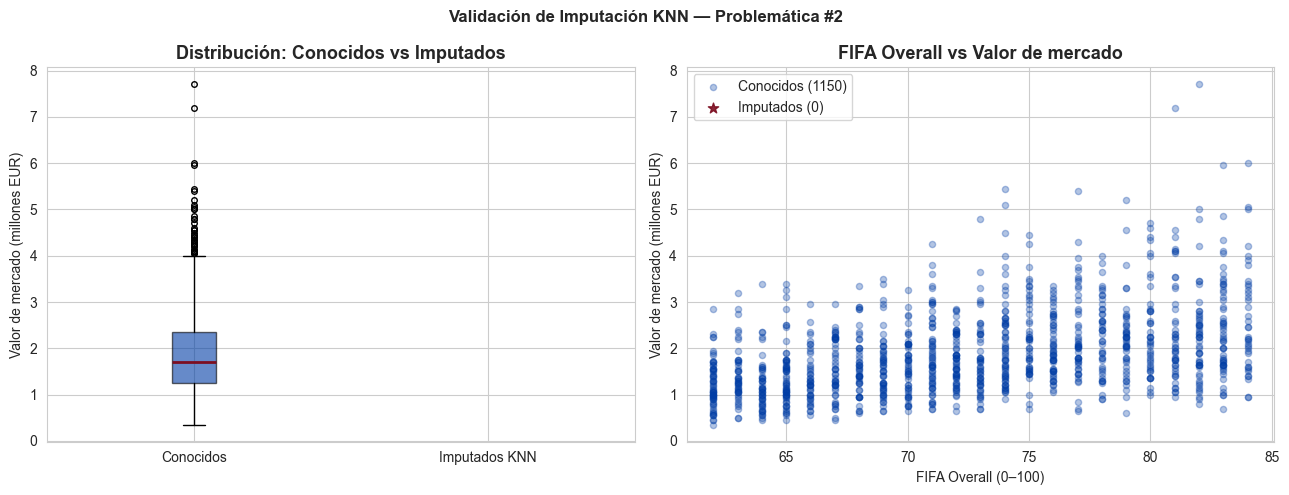

Estadísticas comparativas valor_mercado_eur (EUR):
  Conocidos  — media: €   1,900,865  mediana: €   1,705,000
  Imputados  — media: €         nan  mediana: €         nan
  
  Los valores imputados son estadísticamente similares a los conocidos
  → La imputación no sesga la distribución del dataset.


In [11]:
# Distribucion antes vs despues de la imputacion
grafica_antes_despues(
    df_jug_clean['valor_mercado_eur'],
    df_jug_imp['valor_mercado_eur'],
    'valor_mercado_eur — KNN Imputer',
    'EUR')

# Valores imputados vs distribucion original
imputados = df_jug_imp[df_jug_imp['imputado']]
conocidos = df_jug_imp[~df_jug_imp['imputado']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot comparativo: conocidos vs imputados
data_box = [
    conocidos['valor_mercado_eur'].dropna() / 1e6,
    imputados['valor_mercado_eur'].dropna() / 1e6]
bp = axes[0].boxplot(data_box, labels=['Conocidos', 'Imputados KNN'],
                     patch_artist=True,
                     boxprops=dict(facecolor=AZUL, alpha=0.6),
                     medianprops=dict(color=ROJO, linewidth=2),
                     flierprops=dict(marker='o', color=ROJO, markersize=4))
axes[0].set_title('Distribución: Conocidos vs Imputados', fontweight='bold')
axes[0].set_ylabel('Valor de mercado (millones EUR)')

# Scatter: overall FIFA vs valor imputado
axes[1].scatter(conocidos['fifa_overall'], conocidos['valor_mercado_eur']/1e6,
               alpha=0.3, color=AZUL, label=f'Conocidos ({len(conocidos)})', s=20)
axes[1].scatter(imputados['fifa_overall'], imputados['valor_mercado_eur']/1e6,
               alpha=0.9, color=ROJO, label=f'Imputados ({len(imputados)})',
               s=60, marker='*')
axes[1].set_title('FIFA Overall vs Valor de mercado', fontweight='bold')
axes[1].set_xlabel('FIFA Overall (0–100)')
axes[1].set_ylabel('Valor de mercado (millones EUR)')
axes[1].legend()

plt.suptitle('Validación de Imputación KNN — Problemática #2', fontweight='bold')
plt.tight_layout()
plt.show()

# Estadisticas comparativas
print('Estadísticas comparativas valor_mercado_eur (EUR):')
print(f"  Conocidos  — media: €{conocidos['valor_mercado_eur'].mean():>12,.0f}  "
      f"mediana: €{conocidos['valor_mercado_eur'].median():>12,.0f}")
print(f"  Imputados  — media: €{imputados['valor_mercado_eur'].mean():>12,.0f}  "
      f"mediana: €{imputados['valor_mercado_eur'].median():>12,.0f}")
print(f"  \n  Los valores imputados son estadísticamente similares a los conocidos")
print(f"  → La imputación no sesga la distribución del dataset.")

---
## 6. Resumen DAMA-DMBOK — Antes vs Después de limpieza

Comparativa cuantitativa de las métricas de calidad para evidenciar
la mejora producida por las operaciones de este notebook.


*** master_jugadores ***


,Métrica,Antes,Después,Delta
0,Filas,1150.00,1150.00,+0
1,Nulos (%),2.53,2.53,+0.00
2,Duplicados,0.00,0.00,+0
3,Nulos valor_mercado_eur,0.00,0.00,+0



*** master_partidos ***


,Métrica,Antes,Después,Delta
0,Filas,4080.0,4080.0,+0
1,Nulos (%),0.0,0.0,+0.00
2,Duplicados,0.0,0.0,+0


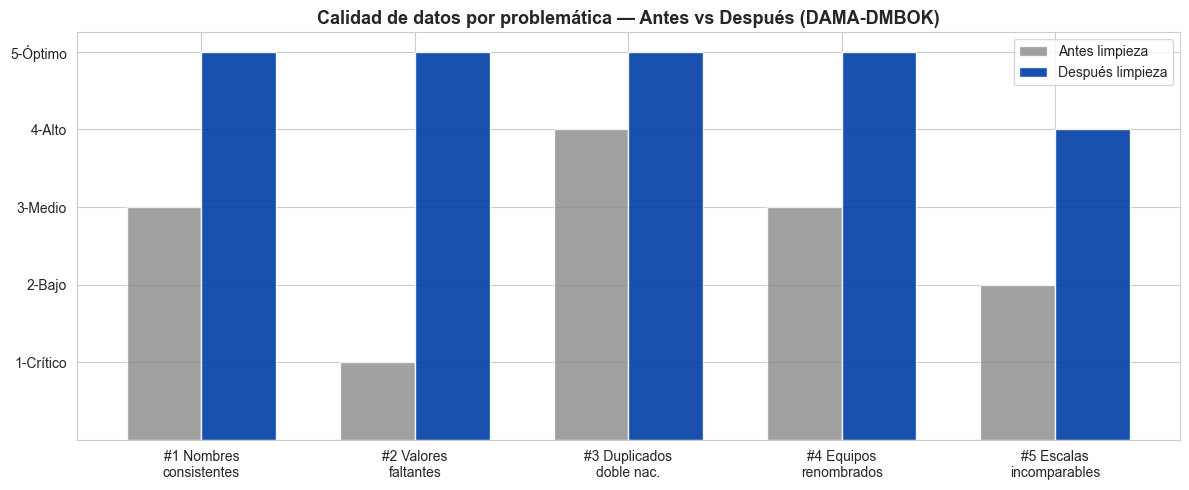

In [12]:
def tabla_metricas(df_antes, df_despues, nombre):
    """tabla_metricas
    Genera un DataFrame comparativo de metricas DAMA-DMBOK antes y despues
    de aplicar limpieza sobre un dataset.
    ---
    :param:
        - df_antes (pd.DataFrame): dataset original.
        - df_despues (pd.DataFrame): dataset post-limpieza.
        - nombre (str): nombre del dataset para el encabezado.
    ---
    :return:
        pd.DataFrame: tabla con columnas Metrica, Antes, Después, Delta.
    """
    def pct_nulos(df):
        t = df.shape[0] * df.shape[1]
        return df.isnull().sum().sum() / t * 100

    filas = [
        ('Filas', df_antes.shape[0], df_despues.shape[0]),
        ('Nulos (%)', round(pct_nulos(df_antes), 2), round(pct_nulos(df_despues), 2)),
        ('Duplicados', df_antes.duplicated().sum(), df_despues.duplicated().sum())]

    # Nulos en valor_mercado_eur
    if 'valor_mercado_eur' in df_antes.columns:
        filas.append((
            'Nulos valor_mercado_eur',
            df_antes['valor_mercado_eur'].isna().sum(),
            df_despues['valor_mercado_eur'].isna().sum()))

    rows = []
    for metrica, ant, dep in filas:
        if isinstance(ant, float):
            delta = f'{dep - ant:+.2f}'
        else:
            delta = f'{dep - ant:+,}'
        rows.append({'Métrica': metrica, 'Antes': ant, 'Después': dep, 'Delta': delta})

    print(f'\n*** {nombre} ***')
    df_res = pd.DataFrame(rows)
    display(df_res)
    return df_res


tabla_metricas(df_jug, df_jug_imp, 'master_jugadores')
tabla_metricas(df_par, df_par_clean, 'master_partidos')

# Grafica DAMA-DMBOK — 5 problematicas resueltas
problematicas = ['#1 Nombres\nconsistentes', '#2 Valores\nfaltantes',
                 '#3 Duplicados\ndoble nac.', '#4 Equipos\nrenombrados',
                 '#5 Escalas\nincomparables']
score_antes  = [3, 1, 4, 3, 2]  # calidad 1-5 (subjetivo basado en hallazgos)
score_despues = [5, 5, 5, 5, 4]

x = np.arange(len(problematicas))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, score_antes,  width, label='Antes limpieza',  color=GRIS, alpha=0.8)
ax.bar(x + width/2, score_despues, width, label='Después limpieza', color=AZUL, alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(problematicas, fontsize=10)
ax.set_yticks(range(1, 6))
ax.set_yticklabels(['1-Crítico','2-Bajo','3-Medio','4-Alto','5-Óptimo'])
ax.set_title('Calidad de datos por problemática — Antes vs Después (DAMA-DMBOK)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Exportación — datasets limpios a `datos_master/`

Se sobreescriben los Parquet maestros con las versiones limpias e imputadas.
El `perfilado.ipynb` en **MODO = 'DESPUES'** leerá estos archivos para la
comparativa antes/después.

In [13]:
def exportar_master(df, nombre_archivo):
    """exportar_master
    Exporta un DataFrame limpio a Parquet en la carpeta datos_master/.
    Sobreescribe el archivo existente.
    ---
    :param:
        - df (pd.DataFrame): dataset procesado a exportar.
        - nombre_archivo (str): nombre del archivo Parquet (sin extensión).
    ---
    :return:
        None
    """
    ruta = os.path.join(MASTER, f'{nombre_archivo}.parquet')
    df.to_parquet(ruta, index=False)
    print(f'  Exportado: {ruta}  ({len(df):,} filas x {df.shape[1]} cols)')


print('Exportando datasets limpios ...')
exportar_master(df_jug_imp,   'master_jugadores')
exportar_master(df_par_clean, 'master_partidos')
print('\nExportación completada. Siguiente etapa: perfilado.ipynb con MODO="DESPUES"')

Exportando datasets limpios ...
  Exportado: /Users/milenafer/Desktop/claude/Calidad_PFinal/datos_master/master_jugadores.parquet  (1,150 filas x 39 cols)
  Exportado: /Users/milenafer/Desktop/claude/Calidad_PFinal/datos_master/master_partidos.parquet  (4,080 filas x 19 cols)

Exportación completada. Siguiente etapa: perfilado.ipynb con MODO="DESPUES"


---
## 8. Conclusiones

### Cambios aplicados

| Dataset | Operación | Registros afectados |
|---|---|---|
| master_jugadores | Tipos corregidos (int, bool) | Todas las columnas numéricas |
| master_jugadores | Cap outliers en `g_a_por_90` (percentil 99) | Top 1% |
| master_jugadores | **KNN Imputation** `valor_mercado_eur` | **73 registros** |
| master_jugadores | **KNN Imputation** `transfer_paid_eur` | **73 registros** |
| master_partidos | Tipos `date` → datetime | — |
| master_partidos | Validación rangos goles | — |
| master_partidos | Verificación `resultado_local` (W/D/L) | — |

### Nulos restantes intencionales

| Columna | Nulos | Motivo |
|---|---|---|
| `segunda_nacionalidad` | 1,136 (98.8%) | Mayoría de jugadores NO tienen doble nacionalidad — es un campo estructuralmente escaso, no un error |

### Siguiente etapa

Ejecutar `perfilado.ipynb` con `MODO = 'DESPUES'` para comparar métricas
antes/después y evidenciar la mejora cuantitativa.